In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import shapely

# Get Nodes shp file - for all country

In [277]:
comp = gpd.read_file('/content/compilation.shp')

In [278]:
comp.columns

Index(['ID', 'ELEVATION', 'TAZ', 'HubID', 'NodeID', 'Model', 'STATCODE',
       'STATNAME', 'STATNAMEEN', 'NODETYPE',
       ...
       'CITYCODE', 'PARKWALKT', 'PARKCAPACI', 'PARKINGTYP', 'PARKMODE', 'TYPE',
       'TAZID', 'TAZ_BSMA_O', 'CENTROIDTY', 'geometry'],
      dtype='object', length=111)

In [279]:
comp = comp[['ID','NodeID','Model','unique_mod','geometry']]

In [280]:
for _, row in comp.iterrows():
  if comp.at[_, 'unique_mod'] == "" or comp.at[_, 'unique_mod'] == None:
    next
  else:
    comp.at[_, 'ID'] = comp.at[_, 'NodeID']

In [183]:
# comp[~comp['unique_mod'].isnull()].loc[:,'ID'] = comp[~comp['unique_mod'].isnull()].loc[:,'NodeID']

In [281]:
comp

,ID,NodeID,Model,unique_mod,geometry
0,400060.0,400060.0,TLV,"3,5",POINT (34.81679 32.16367)
1,400841.0,400841.0,Ashdod,"3,5",POINT (34.60438 31.67666)
2,463984.0,463984.0,Beer_sheva,3,POINT (34.63431 31.32168)
3,400020.0,400020.0,TLV,"3,5",POINT (34.86903 32.31969)
4,400253.0,400253.0,TLV,3,POINT (34.97686 32.23064)
...,...,...,...,...,...
1380,467925.0,NaN,None,None,POINT (34.79766 31.36943)
1381,467926.0,NaN,None,None,POINT (34.78994 31.37185)
1382,467927.0,NaN,None,None,POINT (34.78326 31.38006)
1383,467928.0,NaN,None,None,POINT (34.77617 31.39171)


In [ ]:
# comp['RailMode'] =

In [282]:
comp = comp.dropna(subset='ID')

In [283]:
comp['ID'] = comp['ID'].astype('int')

/usr/local/lib/python3.11/dist-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

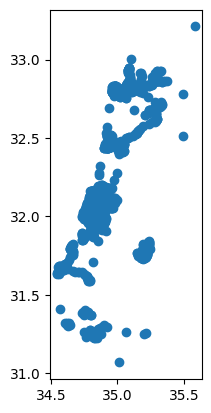

In [285]:
comp['geometry'].plot()

# Join nodes data - mode, area and lines

In [286]:
nodes = gpd.read_file('/content/AllNodes.csv')

In [287]:
nodes.head()

,Node,Include,PlannedMode,Area,Lines,NumLines
0,32001,1,Cable Line,Haifa,c001,1
1,32002,1,Cable Line,Haifa,"c001, c002",2
2,32003,1,Cable Line,Haifa,"c001, c002",2
3,32004,1,Cable Line,Haifa,"c001, c002",2
4,32005,1,Cable Line,Haifa,"c001, c002",2


In [288]:
nodes.dropna(subset='Node', inplace=True)

In [289]:
for _, row in nodes.iterrows():
  if nodes.at[_, 'Node'] == "":
    nodes.at[_, 'Node'] = int(0)
  nodes.at[_, 'Node'] = int(row['Node'])

In [312]:
nodes[nodes['PlannedMode']=='Rail']

,Node,Include,PlannedMode,Area,Lines,NumLines
1681,400060,1,Rail,TLV,"rail_10_1,rail_10_2,rail_11_1,rail_11_2,rail_1...",22
1682,400841,1,Rail,Ashdod-Ashkelon,"rail_11_1,rail_11_2,rail_12_1,rail_12_2,rail_2...",8
1683,463984,1,Rail,BeerSheva,"rail_11_1,rail_11_2,rail_20_1,rail_20_2",4
1684,400020,1,Rail,TLV,"rail_11_1,rail_11_2,rail_12_1,rail_12_2,rail_1...",14
1685,400253,1,Rail,TLV,"rail_10_1,rail_10_2,rail_15_1,rail_15_2,rail_1...",6
...,...,...,...,...,...,...
1769,31633,1,Rail,Haifa,"rail_7_1,rail_7_2,rail_10_1,rail_10_2",4
1770,31640,1,Rail,Haifa,"rail_7_1,rail_7_2,rail_10_1,rail_10_2",4
1771,31634,1,Rail,Haifa,"rail_10_1,rail_10_2",2
1772,31634,1,Rail,Haifa,"rail_7_1,rail_7_2",2


In [313]:
comp.head()

,ID,NodeID,Model,unique_mod,geometry
0,400060,400060.0,TLV,"3,5",POINT (34.81679 32.16367)
1,400841,400841.0,Ashdod,"3,5",POINT (34.60438 31.67666)
2,463984,463984.0,Beer_sheva,3,POINT (34.63431 31.32168)
3,400020,400020.0,TLV,"3,5",POINT (34.86903 32.31969)
4,400253,400253.0,TLV,3,POINT (34.97686 32.23064)


In [178]:
nodes[nodes['Node']==512235]

,Node,Include,PlannedMode,Area,Lines,NumLines
1419,512235,1,LRT,Ashdod-Ashkelon,"Turquoise_N, Turquoise_S",2


In [314]:
comp_nodes = comp.merge(nodes, how='left', left_on='ID', right_on='Node')

In [315]:
# drop null
comp_nodes = comp_nodes.dropna(subset=['ID'])

In [316]:
comp_nodes.head()

,ID,NodeID,Model,unique_mod,geometry,Node,Include,PlannedMode,Area,Lines,NumLines
0,400060,400060.0,TLV,"3,5",POINT (34.81679 32.16367),400060,1,Rail,TLV,"rail_10_1,rail_10_2,rail_11_1,rail_11_2,rail_1...",22
1,400841,400841.0,Ashdod,"3,5",POINT (34.60438 31.67666),400841,1,Rail,Ashdod-Ashkelon,"rail_11_1,rail_11_2,rail_12_1,rail_12_2,rail_2...",8
2,463984,463984.0,Beer_sheva,3,POINT (34.63431 31.32168),463984,1,Rail,BeerSheva,"rail_11_1,rail_11_2,rail_20_1,rail_20_2",4
3,400020,400020.0,TLV,"3,5",POINT (34.86903 32.31969),400020,1,Rail,TLV,"rail_11_1,rail_11_2,rail_12_1,rail_12_2,rail_1...",14
4,400253,400253.0,TLV,3,POINT (34.97686 32.23064),400253,1,Rail,TLV,"rail_10_1,rail_10_2,rail_15_1,rail_15_2,rail_1...",6


# Get Lat/Long from geometry

In [317]:
comp_nodes['Longitude'] = comp_nodes['geometry'].y
comp_nodes['Latitude'] = comp_nodes['geometry'].x

In [318]:
comp_nodes

,ID,NodeID,Model,unique_mod,geometry,Node,Include,PlannedMode,Area,Lines,NumLines,Longitude,Latitude
0,400060,400060.0,TLV,"3,5",POINT (34.81679 32.16367),400060,1,Rail,TLV,"rail_10_1,rail_10_2,rail_11_1,rail_11_2,rail_1...",22,32.163675,34.816795
1,400841,400841.0,Ashdod,"3,5",POINT (34.60438 31.67666),400841,1,Rail,Ashdod-Ashkelon,"rail_11_1,rail_11_2,rail_12_1,rail_12_2,rail_2...",8,31.676659,34.604383
2,463984,463984.0,Beer_sheva,3,POINT (34.63431 31.32168),463984,1,Rail,BeerSheva,"rail_11_1,rail_11_2,rail_20_1,rail_20_2",4,31.321683,34.634312
3,400020,400020.0,TLV,"3,5",POINT (34.86903 32.31969),400020,1,Rail,TLV,"rail_11_1,rail_11_2,rail_12_1,rail_12_2,rail_1...",14,32.319687,34.869029
4,400253,400253.0,TLV,3,POINT (34.97686 32.23064),400253,1,Rail,TLV,"rail_10_1,rail_10_2,rail_15_1,rail_15_2,rail_1...",6,32.230643,34.976865
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1511,467925,NaN,None,None,POINT (34.79766 31.36943),467925,1,LRT,BeerSheva,"4.4_Rahat-Bee'rSheva_Main, 4.4_Bee'rSheva-Raha...",2,31.369428,34.797659
1512,467926,NaN,None,None,POINT (34.78994 31.37185),467926,1,LRT,BeerSheva,"4.4_Rahat-Bee'rSheva_Main, 4.4_Bee'rSheva-Raha...",2,31.371851,34.789942
1513,467927,NaN,None,None,POINT (34.78326 31.38006),467927,1,LRT,BeerSheva,"4.4_Rahat-Bee'rSheva_Main, 4.4_Bee'rSheva-Raha...",2,31.380063,34.783259
1514,467928,NaN,None,None,POINT (34.77617 31.39171),467928,1,LRT,BeerSheva,"4.4_Rahat-Bee'rSheva_Main, 4.4_Bee'rSheva-Raha...",2,31.391714,34.776171


In [319]:
comp_nodes[comp_nodes['ID']==512235]

,ID,NodeID,Model,unique_mod,geometry,Node,Include,PlannedMode,Area,Lines,NumLines,Longitude,Latitude
1303,512235,NaN,None,None,POINT (34.79245 31.90365),512235,1,LRT,Ashdod-Ashkelon,"Turquoise_N, Turquoise_S",2,31.903646,34.792447


# Create H3

In [35]:
# pip install h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.1 MB/s eta 0:00:00


In [201]:
import h3

In [320]:
resolution = 10

In [321]:
comp_nodes['h3_index'] = comp_nodes.apply(lambda row: h3.latlng_to_cell(row['Latitude'], row['Longitude'], resolution), axis=1)

In [322]:
comp_nodes

,ID,NodeID,Model,unique_mod,geometry,Node,Include,PlannedMode,Area,Lines,NumLines,Longitude,Latitude,h3_index
0,400060,400060.0,TLV,"3,5",POINT (34.81679 32.16367),400060,1,Rail,TLV,"rail_10_1,rail_10_2,rail_11_1,rail_11_2,rail_1...",22,32.163675,34.816795,8a3f4dc0895ffff
1,400841,400841.0,Ashdod,"3,5",POINT (34.60438 31.67666),400841,1,Rail,Ashdod-Ashkelon,"rail_11_1,rail_11_2,rail_12_1,rail_12_2,rail_2...",8,31.676659,34.604383,8a3f4c205757fff
2,463984,463984.0,Beer_sheva,3,POINT (34.63431 31.32168),463984,1,Rail,BeerSheva,"rail_11_1,rail_11_2,rail_20_1,rail_20_2",4,31.321683,34.634312,8a3f4c0ccb17fff
3,400020,400020.0,TLV,"3,5",POINT (34.86903 32.31969),400020,1,Rail,TLV,"rail_11_1,rail_11_2,rail_12_1,rail_12_2,rail_1...",14,32.319687,34.869029,8a3f4dc610cffff
4,400253,400253.0,TLV,3,POINT (34.97686 32.23064),400253,1,Rail,TLV,"rail_10_1,rail_10_2,rail_15_1,rail_15_2,rail_1...",6,32.230643,34.976865,8a3f4dd45627fff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1511,467925,NaN,None,None,POINT (34.79766 31.36943),467925,1,LRT,BeerSheva,"4.4_Rahat-Bee'rSheva_Main, 4.4_Bee'rSheva-Raha...",2,31.369428,34.797659,8a3f4c0634b7fff
1512,467926,NaN,None,None,POINT (34.78994 31.37185),467926,1,LRT,BeerSheva,"4.4_Rahat-Bee'rSheva_Main, 4.4_Bee'rSheva-Raha...",2,31.371851,34.789942,8a3f4c044aa7fff
1513,467927,NaN,None,None,POINT (34.78326 31.38006),467927,1,LRT,BeerSheva,"4.4_Rahat-Bee'rSheva_Main, 4.4_Bee'rSheva-Raha...",2,31.380063,34.783259,8a3f4c045c97fff
1514,467928,NaN,None,None,POINT (34.77617 31.39171),467928,1,LRT,BeerSheva,"4.4_Rahat-Bee'rSheva_Main, 4.4_Bee'rSheva-Raha...",2,31.391714,34.776171,8a3f4c045717fff


# group by h3 index

In [323]:
comp_nodes_grouped = comp_nodes.groupby('h3_index').agg({'PlannedMode': set, 'Lines': set, 'NumLines': set, 'Node': set, 'unique_mod': set})

In [240]:
from shapely.geometry import Polygon

In [324]:
def get_boundary(h3_index):
  boundary = h3.cell_to_boundary(h3_index)
  return Polygon(boundary)

In [325]:
def has_neighbor(h3_index):
  neighbors = h3.grid_disk(h3_index, 1)
  neighbors.remove(h3_index)

  return any(n in all_cells for n in neighbors)

In [326]:
all_cells = set(comp_nodes_grouped.index)

In [327]:
comp_nodes_grouped['h3_index'] = comp_nodes_grouped.index
comp_nodes_grouped['has_neighbor'] = comp_nodes_grouped['h3_index'].apply(has_neighbor)

In [328]:
comp_nodes_grouped#[comp_nodes_grouped['PlannedMode']=='{Rail}']

,PlannedMode,Lines,NumLines,Node,unique_mod,h3_index,has_neighbor
h3_index,,,,,,,
8a2da4100a27fff,{Rail},"{rail_1_1,rail_1_2}",{2},{31655},{5},8a2da4100a27fff,False
8a2da4c22257fff,{BRT},{brt022},{1},{36963},{None},8a2da4c22257fff,False
8a2da4c22627fff,{BRT},{brt021},{1},{36959},{None},8a2da4c22627fff,False
8a2da4c2275ffff,{BRT},"{brt021, brt022}",{2},{36961},{None},8a2da4c2275ffff,False
8a2da4c24987fff,{BRT},"{brt011, brt012, brt021, brt022}",{4},{36924},{None},8a2da4c24987fff,False
...,...,...,...,...,...,...,...
8a3f6b79ea07fff,{LRT},"{LRT1, LRT5}",{2},{51201},{None},8a3f6b79ea07fff,False
8a3f6b79ea8ffff,{LRT},"{LRT1, LRT5}",{2},{51200},{None},8a3f6b79ea8ffff,False
8a3f6b79eb6ffff,{LRT},"{LRT1, LRT5}",{2},{51032},{None},8a3f6b79eb6ffff,False


In [329]:
comp_nodes_grouped.head()

,PlannedMode,Lines,NumLines,Node,unique_mod,h3_index,has_neighbor
h3_index,,,,,,,
8a2da4100a27fff,{Rail},"{rail_1_1,rail_1_2}",{2},{31655},{5},8a2da4100a27fff,False
8a2da4c22257fff,{BRT},{brt022},{1},{36963},{None},8a2da4c22257fff,False
8a2da4c22627fff,{BRT},{brt021},{1},{36959},{None},8a2da4c22627fff,False
8a2da4c2275ffff,{BRT},"{brt021, brt022}",{2},{36961},{None},8a2da4c2275ffff,False
8a2da4c24987fff,{BRT},"{brt011, brt012, brt021, brt022}",{4},{36924},{None},8a2da4c24987fff,False


In [330]:
comp_nodes_grouped['Boundaries'] = comp_nodes_grouped['h3_index'].apply(get_boundary)

# Create map of hexagons

In [248]:
import folium


In [333]:
# Center the map on the average of the polygons’ centroids

comp_nodes_grouped['Boundaries_cent_y'] = comp_nodes_grouped['Boundaries'].apply(lambda x: x.centroid.y)
comp_nodes_grouped['Boundaries_cent_x'] = comp_nodes_grouped['Boundaries'].apply(lambda x: x.centroid.x)

center_lat = comp_nodes_grouped['Boundaries_cent_y'].mean()
center_lon = comp_nodes_grouped['Boundaries_cent_x'].mean()

In [338]:
count_comp_nodes = comp_nodes.groupby(['h3_index', 'PlannedMode'])['NumLines'].size().unstack(fill_value=0)

In [339]:
count_comp_nodes['h3_index'] = count_comp_nodes.index

In [340]:
count_comp_nodes['Boundaries'] = count_comp_nodes['h3_index'].apply(get_boundary)

In [341]:
count_comp_nodes

PlannedMode,BRT,Cable Line,Funicular,LRT,Metro,Rail,h3_index,Boundaries
h3_index,,,,,,,,
8a2da4100a27fff,0,0,0,0,0,1,8a2da4100a27fff,POLYGON ((35.58265301924393 33.210083925527144...
8a2da4c22257fff,1,0,0,0,0,0,8a2da4c22257fff,POLYGON ((35.326712236651176 32.92554871174518...
8a2da4c22627fff,1,0,0,0,0,0,8a2da4c22627fff,POLYGON ((35.31703160611188 32.922357120604566...
8a2da4c2275ffff,1,0,0,0,0,0,8a2da4c2275ffff,"POLYGON ((35.31899096798917 32.92353041082285,..."
8a2da4c24987fff,1,0,0,0,0,0,8a2da4c24987fff,"POLYGON ((35.34684915436387 32.86202464606141,..."
...,...,...,...,...,...,...,...,...
8a3f6b79ea07fff,0,0,0,1,0,0,8a3f6b79ea07fff,POLYGON ((35.237732049903876 31.83835780530472...
8a3f6b79ea8ffff,0,0,0,1,0,0,8a3f6b79ea8ffff,POLYGON ((35.234487172891484 31.83732623792413...
8a3f6b79eb6ffff,0,0,0,1,0,0,8a3f6b79eb6ffff,POLYGON ((35.24111742891735 31.842073007406242...


In [342]:
count_comp_nodes['TotalNumLines'] = count_comp_nodes.iloc[:,:6].sum(axis=1)

In [343]:
comp_nodes_grouped = comp_nodes_grouped.set_index('h3_index')

In [344]:
comp_nodes_grouped.head(1)

,PlannedMode,Lines,NumLines,Node,unique_mod,has_neighbor,Boundaries,Boundaries_cent_y,Boundaries_cent_x
h3_index,,,,,,,,,
8a2da4100a27fff,{Rail},"{rail_1_1,rail_1_2}",{2},{31655},{5},False,POLYGON ((35.58265301924393 33.210083925527144...,33.210583,35.582038


In [345]:
count_comp_nodes = count_comp_nodes.join(comp_nodes_grouped[['Node','has_neighbor']], how='left')

In [346]:
count_comp_nodes

,BRT,Cable Line,Funicular,LRT,Metro,Rail,h3_index,Boundaries,TotalNumLines,Node,has_neighbor
h3_index,,,,,,,,,,,
8a2da4100a27fff,0,0,0,0,0,1,8a2da4100a27fff,POLYGON ((35.58265301924393 33.210083925527144...,1,{31655},False
8a2da4c22257fff,1,0,0,0,0,0,8a2da4c22257fff,POLYGON ((35.326712236651176 32.92554871174518...,1,{36963},False
8a2da4c22627fff,1,0,0,0,0,0,8a2da4c22627fff,POLYGON ((35.31703160611188 32.922357120604566...,1,{36959},False
8a2da4c2275ffff,1,0,0,0,0,0,8a2da4c2275ffff,"POLYGON ((35.31899096798917 32.92353041082285,...",1,{36961},False
8a2da4c24987fff,1,0,0,0,0,0,8a2da4c24987fff,"POLYGON ((35.34684915436387 32.86202464606141,...",1,{36924},False
...,...,...,...,...,...,...,...,...,...,...,...
8a3f6b79ea07fff,0,0,0,1,0,0,8a3f6b79ea07fff,POLYGON ((35.237732049903876 31.83835780530472...,1,{51201},False
8a3f6b79ea8ffff,0,0,0,1,0,0,8a3f6b79ea8ffff,POLYGON ((35.234487172891484 31.83732623792413...,1,{51200},False
8a3f6b79eb6ffff,0,0,0,1,0,0,8a3f6b79eb6ffff,POLYGON ((35.24111742891735 31.842073007406242...,1,{51032},False


In [347]:
gdf = gpd.GeoDataFrame(count_comp_nodes, geometry='Boundaries')

In [348]:
gdf.drop('h3_index', axis=1, inplace=True)

In [349]:
gdf.to_file('/content/count_comp_nodes_02-02-2025.shp', driver='ESRI Shapefile')

<ipython-input-349-70dbca4493ce>:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('/content/count_comp_nodes_02-02-2025.shp', driver='ESRI Shapefile')
/usr/local/lib/python3.11/dist-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'TotalNumLines' to 'TotalNumLi'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'has_neighbor' to 'has_neighb'
  ogr_write(


In [350]:
cols = [col for col in count_comp_nodes.iloc[:,:5]]
count_comp_nodes['NumModes'] = (count_comp_nodes[cols]/count_comp_nodes[cols]).sum(axis=1)

In [351]:
count_comp_nodes['ScoreByMode'] = (count_comp_nodes[cols] * [2, 1, 1, 3, 3]).sum(axis=1)

In [352]:
# Create a folium map
m = folium.Map(location=[center_lat, center_lon], tiles="cartodbpositron", zoom_start=10)

In [353]:
import branca.colormap as cm

In [354]:
colormap = cm.LinearColormap(colors=['#ffcccc', '#ff0000'], vmin=count_comp_nodes['TotalNumLines'].min(), vmax=count_comp_nodes['TotalNumLines'].max())

In [355]:
count_comp_nodes.head(1)

,BRT,Cable Line,Funicular,LRT,Metro,Rail,h3_index,Boundaries,TotalNumLines,Node,has_neighbor,NumModes,ScoreByMode
h3_index,,,,,,,,,,,,,
8a2da4100a27fff,0,0,0,0,0,1,8a2da4100a27fff,POLYGON ((35.58265301924393 33.210083925527144...,1,{31655},False,0.0,0


In [356]:
for _, row in count_comp_nodes.iterrows():
  numLines = row['TotalNumLines']
  numModes = row['NumModes']
  color = colormap(numLines * numModes)
  folium.GeoJson(
        data=row['Boundaries'].__geo_interface__,
        color = color,
        popup=folium.Popup(f"ID: {row['h3_index']}\
                           <br>BRT: {row['BRT']}\
                           <br>LRT: {row['LRT']}\
                           <br>Metro: {row['Metro']}\
                           <br>Rail: {row['Rail']}\
                           <br>Cable Line: {row['Cable Line']}\
                           <br>Funicular: {row['Funicular']}\
                           <br>Nodes: {set(row['Node'])}\
                           <br><br>Has Neighbor: {row['has_neighbor']}\
                           <br>Score: {numLines * numModes}\
                           <br>Weighted Score: {row['ScoreByMode']}")
    ).add_to(m)


In [357]:
m

Output hidden; open in https://colab.research.google.com to view.